# Forecasting Daily Orders with Prophet

This notebook builds a daily order-volume forecast using Meta's [Prophet](https://facebook.github.io/prophet/) library and tests whether adding Belgian public holidays as a regressor improves accuracy. The data is a synthetic order log with one row per day.

**Approach**

1. Hold out the final 56 days (8 weeks) as a test set.
2. Fit a baseline Prophet model with weekly and yearly seasonality.
3. Score it on the holdout using MAPE and WMAPE.
4. Decompose the forecast into trend and seasonal components.
5. Refit with Belgian public holidays added as a regressor and compare.
6. Inspect which holidays the model judges most impactful.

## 1. Load the data

The dataset records total daily orders together with two distribution-centre splits and a promo flag. For Prophet we only need the date and target, renamed to **ds** and **y** which are the column names Prophet expects.

In [42]:
import pandas as pd

df = pd.read_csv("../files/synthetic_orders.csv", parse_dates=["date"])
prophet_df = df.rename(columns={"date": "ds", "orders_total": "y"})
prophet_df.head()

,ds,y,orders_dc1,orders_dc2,is_promo,day_of_week,month
0,2024-01-01,3701,2039,1662,0,Monday,1
1,2024-01-02,3596,2267,1329,0,Tuesday,1
2,2024-01-03,3340,1784,1556,0,Wednesday,1
3,2024-01-04,3406,2130,1276,0,Thursday,1
4,2024-01-05,3120,1963,1157,0,Friday,1


## 2. Hold out a test window and fit a baseline model

We reserve the last 56 days (8 weeks, two full weekly cycles) for evaluation. The baseline Prophet model captures trend plus weekly and yearly seasonality. Daily seasonality is disabled because the data is already at daily granularity.

In [43]:
from prophet import Prophet
import numpy as np

train = prophet_df.iloc[:-56]
test = prophet_df.iloc[-56:]

baseline = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False,
)
baseline.fit(train[["ds", "y"]])

19:29:51 - cmdstanpy - INFO - Chain [1] start processing
19:29:52 - cmdstanpy - INFO - Chain [1] done processing


## 3. Forecast the holdout window and score it

We score predictions against actuals using two error metrics:

- **MAPE** (Mean Absolute Percentage Error) : average per-day error, treats every day equally.
- **WMAPE** (Weighted MAPE) : total absolute error divided by total volume, this weights high-volume days more heavily.

WMAPE is better since being 10% off on a 5,000-order day matters more than the same percentage on a 500-order day.

In [44]:
def mape(actual, forecast):
    return np.mean(np.abs((actual - forecast) / actual)) * 100

def wmape(actual, forecast):
    return np.sum(np.abs(actual - forecast)) / np.sum(actual) * 100

future = baseline.make_future_dataframe(periods=56)
forecast = baseline.predict(future)

In [45]:
actual = test["y"].values
predicted = forecast["yhat"].iloc[-56:].values

print(f"MAPE:  {mape(actual, predicted):.3f}%")
print(f"WMAPE: {wmape(actual, predicted):.3f}%")

MAPE:  8.235%
WMAPE: 10.282%


## 4. Decompose the forecast

Prophet's **plot_components** splits the forecast into its additive parts: trend, weekly seasonality, and yearly seasonality.

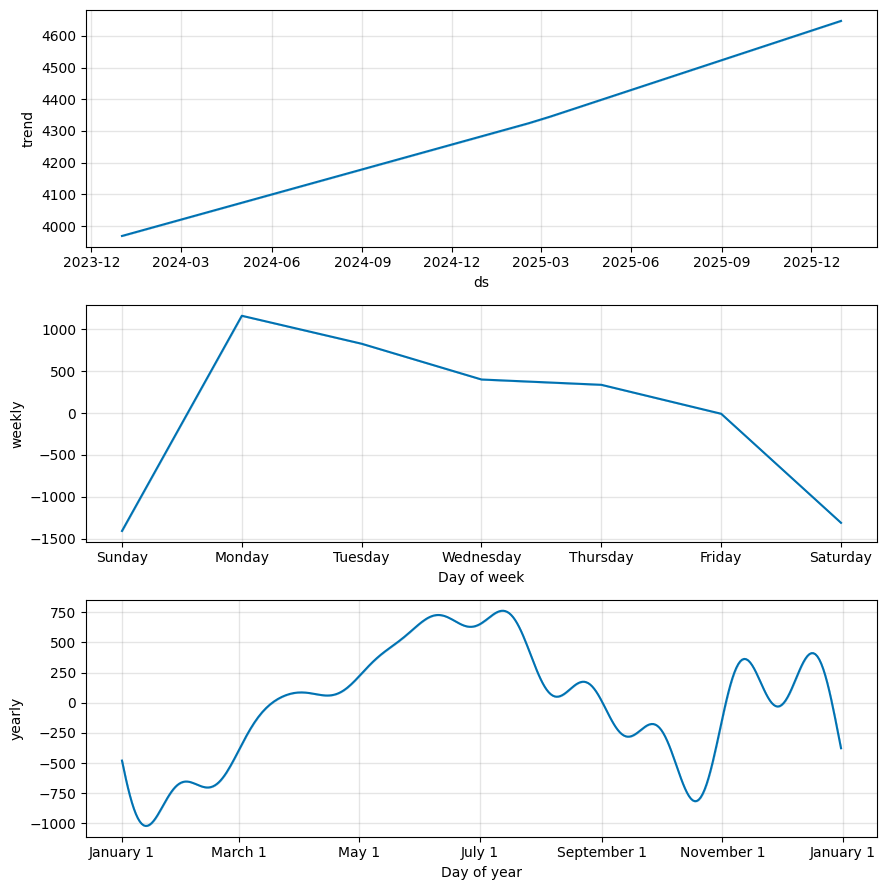

In [46]:
baseline.plot_components(forecast);

**Reading the decomposition**

- **Trend** : order volume is rising steadily across the observed period.
- **Weekly** : Monday is the heaviest day, volume tapers through the week and bottoms out at the weekend.
- **Yearly** : clear seasonal peaks and troughs at predictable times of year, which the model leans on when forecasting the holdout window.

## 5. Belgian public holidays as a regressor

Public holidays can disrupt order patterns. Prophet uses **add_country_holidays**, which loads an official holiday calendar and lets the model learn a separate effect per holiday.

In [47]:
with_holidays = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
)
with_holidays.add_country_holidays(country_name="BE")
with_holidays.fit(train[["ds", "y"]])

19:29:55 - cmdstanpy - INFO - Chain [1] start processing
19:29:56 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
forecast_h = with_holidays.predict(test[["ds"]])
actual_h = test["y"].values
predicted_h = forecast_h["yhat"].values

print(f"MAPE:  {mape(actual_h, predicted_h):.3f}%")
print(f"WMAPE: {wmape(actual_h, predicted_h):.3f}%")

MAPE:  8.262%
WMAPE: 10.263%


## 6. Which holidays move the needle?

The fitted model attaches a learned effect (in orders) to every holiday date. Filtering the `holidays` column to non-zero rows and sorting by magnitude shows which dates the model expects to deviate most from the seasonal baseline.

In [49]:
holiday_effects = forecast_h[["ds", "holidays"]]
holiday_effects = holiday_effects[holiday_effects["holidays"] != 0]

In [50]:
holiday_effects.sort_values("holidays", ascending=False).head()

,ds,holidays
5,2025-11-11,282.302693
49,2025-12-25,-74.492922


## 7. Takeaways and next steps

- The baseline Prophet model lands at roughly 8% MAPE / 10% WMAPE on an 8-week holdout
- Trend, weekly, and yearly components all carry signal: Monday is the busiest day and yearly seasonality is well-defined.
- Adding Belgian public holidays did **not** materially improve accuracy on this dataset. The model only attached a meaningful effect to Armistice Day (11 November); most other Belgian holidays produced negligible lifts in the holdout window.